In [2]:
import sys
sys.path.append("../src")

from preprocessing import preprocess_dataframe, combine_comment_rule, get_augmented_dataframe
import pandas as pd

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


In [3]:
%run 00_eda.ipynb

In [4]:
train_df.head()

,row_id,body,rule,subreddit,positive_example_1,positive_example_2,negative_example_1,negative_example_2,rule_violation
0,0,Banks don't want you to know this! Click here ...,"No Advertising: Spam, referral links, unsolici...",Futurology,If you could tell your younger self something ...,hunt for lady for jack off in neighbourhood ht...,Watch Golden Globe Awards 2017 Live Online in ...,"DOUBLE CEE x BANDS EPPS - ""BIRDS""\n\nDOWNLOAD/...",0
1,1,SD Stream [ ENG Link 1] (http://www.sportsstre...,"No Advertising: Spam, referral links, unsolici...",soccerstreams,[I wanna kiss you all over! Stunning!](http://...,LOLGA.COM is One of the First Professional Onl...,#Rapper \n🚨Straight Outta Cross Keys SC 🚨YouTu...,[15 Amazing Hidden Features Of Google Search Y...,0
2,2,Lol. Try appealing the ban and say you won't d...,No legal advice: Do not offer or request legal...,pcmasterrace,Don't break up with him or call the cops. If ...,It'll be dismissed: https://en.wikipedia.org/w...,Where is there a site that still works where y...,Because this statement of his is true. It isn'...,1
3,3,she will come your home open her legs with an...,"No Advertising: Spam, referral links, unsolici...",sex,Selling Tyrande codes for 3€ to paypal. PM. \n...,tight pussy watch for your cock get her at thi...,NSFW(obviously) http://spankbang.com/iy3u/vide...,Good News ::Download WhatsApp 2.16.230 APK for...,1
4,4,code free tyrande --->>> [Imgur](http://i.imgu...,"No Advertising: Spam, referral links, unsolici...",hearthstone,wow!! amazing reminds me of the old days.Well...,seek for lady for sex in around http://p77.pl/...,must be watch movie https://sites.google.com/s...,We're streaming Pokemon Veitnamese Crystal RIG...,1


In [5]:
# Create augmented dataset (this now has more rows, example columns removed)
train_df_augmented = get_augmented_dataframe(train_df, test_df)

print(f"\nData augmentation complete!")
print(f"Original rows (body only): {len(train_df)}")
print(f"Augmented rows (body + examples): {len(train_df_augmented)}")
print(f"New rows added: {len(train_df_augmented) - len(train_df)}")
print(f"\nLabel distribution:")
print(train_df_augmented['rule_violation'].value_counts())
print(f"\nColumns in new df (examples removed): {list(train_df_augmented.columns)}")

# Clean only the main body and rule in the train dataset for model input
columns_to_clean = ["body", "rule"]
train_df_clean = preprocess_dataframe(train_df_augmented, columns_to_clean, label_column="rule_violation")

# Apply combine_comment_rule to the cleaned dataset
train_df_clean = combine_comment_rule(train_df_clean, "body", "rule", "combined_text")

print(f"\nApplied combine_comment_rule to augmented dataset")
print(f"Final columns after augmentation and unique comment-rule pair combination: {list(train_df_clean.columns)}")
print(f"Total rows after cleaning: {len(train_df_clean)}")


Data augmentation complete!
Original rows (body only): 2029
Augmented rows (body + examples): 8310
New rows added: 6281

Label distribution:
rule_violation
1    4229
0    4081
Name: count, dtype: int64

Columns in new df (examples removed): ['body', 'rule', 'subreddit', 'rule_violation', 'source']

Applied combine_comment_rule to augmented dataset
Final columns after augmentation and unique comment-rule pair combination: ['body', 'rule', 'subreddit', 'rule_violation', 'source', 'combined_text']
Total rows after cleaning: 8310


In [ ]:
train_df_clean.head()

,body,rule,subreddit,rule_violation,source,combined_text
0,FindSexToday . com - free girls for sex worldw...,"No Advertising: Spam, referral links, unsolici...",gonewild,1,train_aug_positive,FindSexToday . com - free girls for sex worldw...
1,see there hooters sweet <URL>,"No Advertising: Spam, referral links, unsolici...",BlackPeopleTwitter,1,train_aug_positive,see there hooters sweet <URL> [SEP] No Adverti...
2,buy my shirt because i want to buy ganja!: <URL>,"No Advertising: Spam, referral links, unsolici...",soccerstreams,1,train_aug_positive,buy my shirt because i want to buy ganja!: <UR...
3,Smashing evidence under subpoena is not violat...,No legal advice: Do not offer or request legal...,politics,1,original,Smashing evidence under subpoena is not violat...
4,"if she doesn't want to be a ""right wing target...",No legal advice: Do not offer or request legal...,hillaryclinton,1,original,"if she doesn't want to be a ""right wing target..."


In [7]:
pd.set_option('display.max_colwidth', None)
train_df_clean["combined_text"].head()

0                                                                                                                                                                                                                                                                                                    FindSexToday . com - free girls for sex worldwide 44XtPDKtcnDY30! [SEP] No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.
1                                                                                                                                                                                                                                                                                                                                        see there hooters sweet <URL> [SEP] No Advertising: Spam, referral links, unsolicited advertising, and promotional content are not allowed.
2                                                             

In [7]:
train_df_clean.to_csv("../data/processed/train_cleaned.csv", index=False)

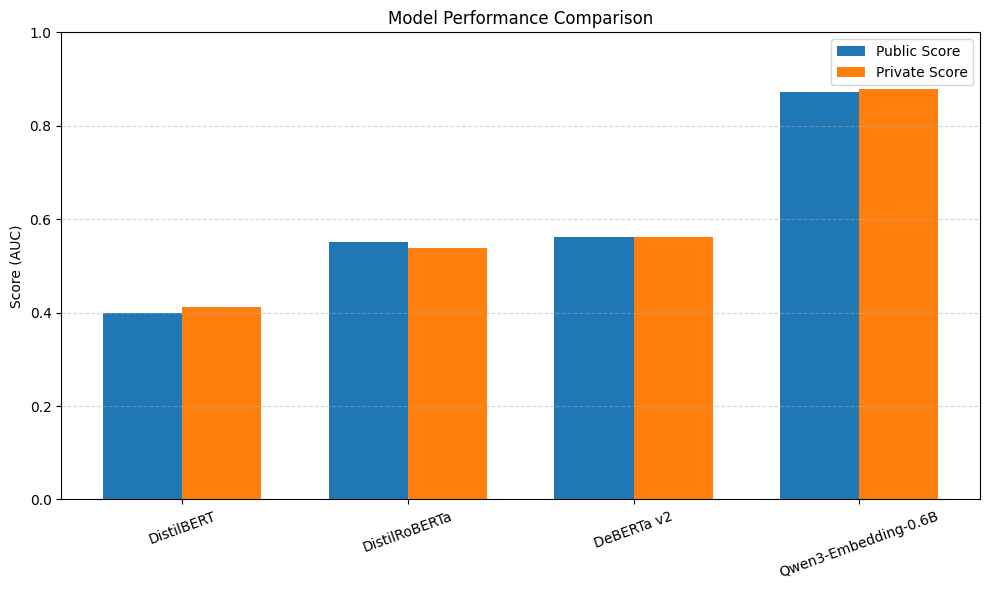

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Model names and scores
models = [
    "DistilBERT",
    "DistilRoBERTa",
    "DeBERTa v2",
    "Qwen3-Embedding-0.6B"
]

public_scores = [0.40012, 0.55196, 0.56281, 0.87178]
private_scores = [0.41106, 0.53920, 0.56276, 0.87873]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, public_scores, width, label='Public Score')
plt.bar(x + width/2, private_scores, width, label='Private Score')

plt.ylabel("Score (AUC)")
plt.title("Model Performance Comparison")
plt.xticks(x, models, rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()